# Spaceship Titanic

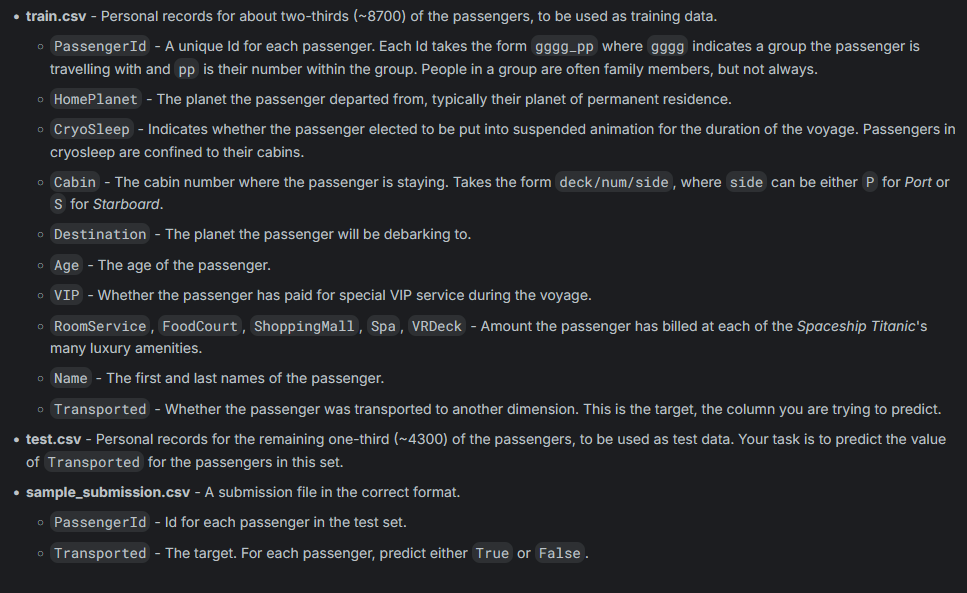

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
test = pd.read_csv('test(1).csv')
train = pd.read_csv('train(1).csv')

In [3]:
train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


# EDA

In [4]:
train[train.duplicated]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [6]:
def preprocess_dataset(df, is_train=True):
    # Делаем копию исходных данных
    data = df.copy()

    # 1. Выделяем Group_Id и Passenger_Num, если они еще не выделены
    if "Group_Id" not in data.columns:
        data["Group_Id"] = data["PassengerId"].apply(lambda x: x.split("_")[0])
        data["Passenger_Num"] = data["PassengerId"].apply(
            lambda x: int(x.split("_")[1])
        )

    # 2. Обработка расходов на основе криосна
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in spend_cols:
        # Если в криосне — расходы точно 0
        data.loc[(data["CryoSleep"] == True) & (data[col].isna()), col] = 0.0
        # Остальные пропущенные расходы заполняем медианой
        data[col] = data[col].fillna(data[col].median())

    # 3. Заполнение базовых признаков (Возраст и Категории)
    data["Age"] = data["Age"].fillna(data["Age"].median())

    cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
    for col in cat_cols:
        data[col] = data[col].fillna(data[col].mode()[0])

    # 4. Разделение и заполнение признаков каюты (Cabin)
    data["Cabin"] = data["Cabin"].fillna("Unknown/Unknown/Unknown")
    data[["Cabin_Deck", "Cabin_Num", "Cabin_Side"]] = data["Cabin"].str.split(
        "/", expand=True
    )

    data["Cabin_Num"] = pd.to_numeric(data["Cabin_Num"], errors="coerce")
    data["Cabin_Num"] = data["Cabin_Num"].fillna(data["Cabin_Num"].median())

    data["Cabin_Deck"] = data["Cabin_Deck"].replace(
        "Unknown", data["Cabin_Deck"].mode()[0]
    )
    data["Cabin_Side"] = data["Cabin_Side"].replace(
        "Unknown", data["Cabin_Side"].mode()[0]
    )

    # Удаляем старые ненужные столбцы
    cols_to_drop = ["Cabin", "Name"]
    if "PassengerId" in data.columns:
        cols_to_drop.append("PassengerId")
    data = data.drop(columns=cols_to_drop)

    # 5. One-Hot Encoding категориальных признаков
    encode_cols = [
        "HomePlanet",
        "CryoSleep",
        "Destination",
        "VIP",
        "Cabin_Deck",
        "Cabin_Side",
    ]
    data = pd.get_dummies(data, columns=encode_cols, drop_first=True)

    # 6. Разделение признаков и таргета
    if is_train:
        X = data.drop(columns=["Transported", "Group_Id", "Passenger_Num"])
        y = data["Transported"].astype(int)
        return X, y
    else:
        X = data.drop(columns=["Group_Id", "Passenger_Num"])
        return X


# Training

In [8]:
# Обработка через функцию
X_train_full, y_train_full = preprocess_dataset(train, is_train=True)
X_test = preprocess_dataset(test, is_train=False)

# Выравниваем столбцы
X_train_full, X_test = X_train_full.align(X_test, join="left", axis=1, fill_value=0)

# Делим на трейн и валидацию
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
print(f"Данные готовы! Размер обучающей выборки: {X_tr.shape}")

Данные готовы! Размер обучающей выборки: (6954, 21)


In [9]:
# 1. Random Forest (Случайный лес)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8)
rf_model.fit(X_tr, y_tr)
rf_acc = accuracy_score(y_val, rf_model.predict(X_val))

# 2. LightGBM (Градиентный бустинг)
lgb_model = lgb.LGBMClassifier(random_state=42, n_estimators=150, max_depth=6, verbose=-1)
lgb_model.fit(X_tr, y_tr)
lgb_acc = accuracy_score(y_val, lgb_model.predict(X_val))

# 3. CatBoost (Градиентный бустинг)
cb_model = cb.CatBoostClassifier(random_state=42, iterations=150, depth=6, verbose=0)
cb_model.fit(X_tr, y_tr)
cb_acc = accuracy_score(y_val, cb_model.predict(X_val))

# Вывод результатов
print(f"Accuracy Random Forest: **{rf_acc:.4f}**")
print(f"Accuracy LightGBM:     **{lgb_acc:.4f}**")
print(f"Accuracy CatBoost:     **{cb_acc:.4f}**")


Accuracy Random Forest: **0.7918**
Accuracy LightGBM:     **0.8131**
Accuracy CatBoost:     **0.8160**


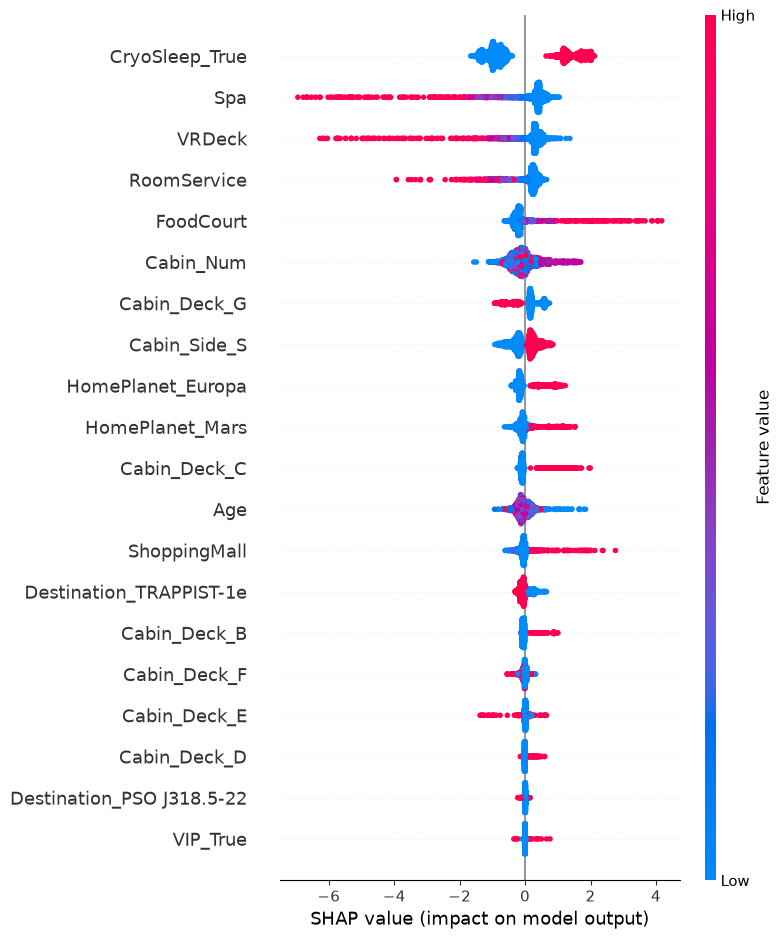

In [10]:
# Инициализируем SHAP Explainer для древесных моделей
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_val)

# Строим Summary Plot (График важности и направления влияния признаков)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val)


In [15]:
def preprocess_dataset_v3(train_raw, test_raw):
    """Продвинутый пайплайн с извлечением семейных и групповых связей."""
    # Объединяем датасеты для корректного подсчета размеров групп и семей по всей выборке
    df = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)

    # 1. Парсинг ID группы и номера внутри группы
    df["Group_Id"] = df["PassengerId"].apply(lambda x: x.split("_")[0])
    df["Passenger_Num"] = df["PassengerId"].apply(lambda x: int(x.split("_")[1]))

    # Подсчет размера группы
    group_sizes = df["Group_Id"].value_counts()
    df["Group_Size"] = df["Group_Id"].map(group_sizes)
    df["Is_Alone"] = (df["Group_Size"] == 1).astype(int)

    # 2. Извлечение Фамилии и размера семьи
    df["LastName"] = df["Name"].fillna("Unknown").apply(lambda x: x.split()[-1])
    # Одиночками по фамилии считаем только реальные семьи (исключая Unknown)
    family_sizes = df[df["LastName"] != "Unknown"]["LastName"].value_counts()
    df["Family_Size"] = df["LastName"].map(family_sizes).fillna(1)

    # 3. Логическое заполнение расходов для тех, кто в криосне
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in spend_cols:
        df.loc[(df["CryoSleep"] == True) & (df[col].isna()), col] = 0.0
        df[col] = df[col].fillna(df[col].median())

    # Агрегаты по тратам
    df["Luxury_Spend"] = df["Spa"] + df["VRDeck"] + df["RoomService"]
    df["Total_Spend"] = df[spend_cols].sum(axis=1)

    # 4. Заполнение базовых признаков
    df["Age"] = df["Age"].fillna(df["Age"].median())

    cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # 5. Парсинг каюты
    df["Cabin"] = df["Cabin"].fillna("Unknown/Unknown/Unknown")
    df[["Cabin_Deck", "Cabin_Num", "Cabin_Side"]] = df["Cabin"].str.split(
        "/", expand=True
    )
    df["Cabin_Num"] = pd.to_numeric(df["Cabin_Num"], errors="coerce")
    df["Cabin_Num"] = df["Cabin_Num"].fillna(df["Cabin_Num"].median())
    df["Cabin_Deck"] = df["Cabin_Deck"].replace("Unknown", df["Cabin_Deck"].mode()[0])
    df["Cabin_Side"] = df["Cabin_Side"].replace("Unknown", df["Cabin_Side"].mode()[0])

    # 6. Дизайн признака: групповой таргет (сколько СОСЕДЕЙ по группе спаслось)
    # Считаем сумму спасенных в группе по train-части
    group_transported_sum = (
        df.groupby("Group_Id")["Transported"].transform("sum").fillna(0)
    )
    group_transported_count = (
        df.groupby("Group_Id")["Transported"].transform("count").fillna(0)
    )

    # Вычитаем самого пассажира, чтобы не было утечки (Data Leakage)
    # Если пассажир улетел (Transported=True), вычитаем 1 из суммы
    df["Group_Surv_Rate"] = (
        group_transported_sum - df["Transported"].fillna(0).astype(int)
    ) / (group_transported_count - 1).replace(0, 1)

    # То же самое для каюты (совпадение по палубе, номеру и стороне)
    cabin_transported_sum = (
        df.groupby("Cabin")["Transported"].transform("sum").fillna(0)
    )
    cabin_transported_count = (
        df.groupby("Cabin")["Transported"].transform("count").fillna(0)
    )
    df["Cabin_Surv_Rate"] = (
        cabin_transported_sum - df["Transported"].fillna(0).astype(int)
    ) / (cabin_transported_count - 1).replace(0, 1)

    # 7. Очистка от мусора
    df = df.drop(columns=["Cabin", "Name", "LastName"])

    # 8. Кодирование категорий (One-Hot)
    encode_cols = [
        "HomePlanet",
        "CryoSleep",
        "Destination",
        "VIP",
        "Cabin_Deck",
        "Cabin_Side",
    ]
    df = pd.get_dummies(df, columns=encode_cols, drop_first=True)

    # 9. Возвращаем обратно разделенные train и test
    train_processed = df[df["Transported"].notna()].copy()
    test_processed = df[df["Transported"].isna()].copy()

    X_train = train_processed.drop(
        columns=["Transported", "PassengerId", "Group_Id"]
    )
    y_train = train_processed["Transported"].astype(int)

    X_test = test_processed.drop(columns=["Transported", "PassengerId", "Group_Id"])

    return X_train, y_train, X_test


In [17]:
import catboost as cb
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

# Загружаем чистые исходники
train_raw = pd.read_csv("train(1).csv")
test_raw = pd.read_csv("test(1).csv")

# Применяем v3 пайплайн
X_train_v3, y_train_v3, X_test_v3 = preprocess_dataset_v3(train_raw, test_raw)
X_train_v3, X_test_v3 = X_train_v3.align(
    X_test_v3, join="left", axis=1, fill_value=0
)

# Кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []
test_predictions = np.zeros(len(X_test_v3))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v3, y_train_v3)):
    X_tr, y_tr = X_train_v3.iloc[train_idx], y_train_v3.iloc[train_idx]
    X_va, y_va = X_train_v3.iloc[val_idx], y_train_v3.iloc[val_idx]

    # Используем CatBoost с небольшим тюнингом под новые фичи
    model = cb.CatBoostClassifier(
        random_state=42,
        iterations=500,
        learning_rate=0.04,
        depth=5,
        verbose=0,
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)

    preds_val = model.predict(X_va)
    score = accuracy_score(y_va, preds_val)
    val_scores.append(score)
    print(f"Фолд {fold+1} Accuracy: **{score:.4f}**")

print(f"\nНовая средняя точность v3 на K-Fold: **{np.mean(val_scores):.4f}**")


Фолд 1 Accuracy: **0.8148**
Фолд 2 Accuracy: **0.8206**
Фолд 3 Accuracy: **0.8252**
Фолд 4 Accuracy: **0.8280**
Фолд 5 Accuracy: **0.8096**

Новая средняя точность v3 на K-Fold: **0.8196**


In [18]:
# Фиксируем K-Fold заново
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_scores = []
# Массив для накопления предсказаний пяти моделей
test_predictions = np.zeros(len(X_test_v3))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v3, y_train_v3)):
    X_tr, y_tr = X_train_v3.iloc[train_idx], y_train_v3.iloc[train_idx]
    X_va, y_va = X_train_v3.iloc[val_idx], y_train_v3.iloc[val_idx]
    
    model = cb.CatBoostClassifier(
        random_state=42, 
        iterations=500, 
        learning_rate=0.04, 
        depth=5, 
        verbose=0
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
    
    # Считаем точность для контроля
    preds_val = model.predict(X_va)
    val_scores.append(accuracy_score(y_va, preds_val))
    
    # КРИТИЧЕСКОЕ ИСПРАВЛЕНИЕ: накапливаем вероятности предсказаний для теста
    # predict_proba[:, 1] выдает вероятность класса 1 (пассажир транспортирован)
    test_predictions += model.predict_proba(X_test_v3)[:, 1] / skf.n_splits

# Переводим усредненные вероятности в True/False по порогу 0.5
final_preds_binary = (test_predictions >= 0.5).astype(bool)

# Сохраняем финальный сабмит
submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Transported": final_preds_binary
})

submission.to_csv("submission_top_v3.csv", index=False)
print("Файл **submission_top_v3.csv** успешно сгенерирован и содержит корректные ответы!")


Файл **submission_top_v3.csv** успешно сгенерирован и содержит корректные ответы!


In [22]:
# Принудительно переводим проблемные колонки в float32 в обоих датасетах
for col in ['Group_Surv_Rate', 'Cabin_Surv_Rate']:
    X_train_v3[col] = pd.to_numeric(X_train_v3[col], errors='coerce').astype('float32')
    X_test_v3[col] = pd.to_numeric(X_test_v3[col], errors='coerce').astype('float32')

# Заново инициализируем K-Fold и списки
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []
blend_test_predictions = np.zeros(len(X_test_v3))

# Запуск исправленного цикла блендинга
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v3, y_train_v3)):
    X_tr, y_tr = X_train_v3.iloc[train_idx], y_train_v3.iloc[train_idx]
    X_va, y_va = X_train_v3.iloc[val_idx], y_train_v3.iloc[val_idx]
    
    # Модель 1: CatBoost
    model_cb = cb.CatBoostClassifier(random_state=42, iterations=500, learning_rate=0.04, depth=5, verbose=0)
    model_cb.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
    
    # Модель 2: XGBoost (теперь запустится без ошибок)
    model_xgb = XGBClassifier(
        random_state=42, 
        n_estimators=400, 
        learning_rate=0.03, 
        max_depth=5, 
        early_stopping_rounds=50,
        eval_metric='logloss'
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    
    # Считаем Blend Accuracy
    val_preds_cb = model_cb.predict_proba(X_va)[:, 1]
    val_preds_xgb = model_xgb.predict_proba(X_va)[:, 1]
    blend_val_preds = (val_preds_cb + val_preds_xgb) / 2
    blend_val_labels = (blend_val_preds >= 0.5).astype(int)
    
    score = accuracy_score(y_va, blend_val_labels)
    val_scores.append(score)
    print(f"Фолд {fold+1} Blend Accuracy: **{score:.4f}**")
    
    # Накапливаем предсказания для теста
    test_preds_cb = model_cb.predict_proba(X_test_v3)[:, 1]
    test_preds_xgb = model_xgb.predict_proba(X_test_v3)[:, 1]
    blend_test_predictions += (test_preds_cb + test_preds_xgb) / (2 * skf.n_splits)

print(f"\nСредняя точность БЛЕНДА на кросс-валидации: **{np.mean(val_scores):.4f}**")


Фолд 1 Blend Accuracy: **0.8171**
Фолд 2 Blend Accuracy: **0.8160**
Фолд 3 Blend Accuracy: **0.8240**
Фолд 4 Blend Accuracy: **0.8268**
Фолд 5 Blend Accuracy: **0.8101**

Средняя точность БЛЕНДА на кросс-валидации: **0.8188**


In [23]:
# Переводим усредненные вероятности трех моделей в бинарный формат
final_blend_preds = (blend_test_predictions >= 0.5).astype(bool)

submission_blend = pd.DataFrame(
    {"PassengerId": test_raw["PassengerId"], "Transported": final_blend_preds}
)

submission_blend.to_csv("submission_blend_xg_cb.csv", index=False)
print("Файл **submission_blend_xg_cb.csv** готов к отправке!")


Файл **submission_blend_xg_cb.csv** готов к отправке!


In [33]:
import catboost as cb
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# =====================================================================
# 1. АБСОЛЮТНО СТАБИЛЬНЫЙ ПАЙПЛАЙН ПРЕДОБРАБОТКИ (БЕЗ БАГОВ)
# =====================================================================
train_raw = pd.read_csv("train(1).csv")
test_raw = pd.read_csv("test(1).csv")


def preprocess_safe_v5(df, is_train=True):
    data = df.copy()

    # Корректный и надежный парсинг PassengerId без apply-лямбд
    data["Group_Id"] = data["PassengerId"].str.split("_").str[0]
    data["Passenger_Num"] = (
        data["PassengerId"].str.split("_").str[1].astype(int)
    )

    # Логическое заполнение расходов для тех, кто в криосне
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in spend_cols:
        data.loc[(data["CryoSleep"] == True) & (data[col].isna()), col] = 0.0
        data[col] = data[col].fillna(data[col].median())

    # Суммарные траты
    data["Total_Spend"] = data[spend_cols].sum(axis=1)

    # Заполнение пропусков медианой и модой (с явным извлечением .values[0])
    data["Age"] = data["Age"].fillna(data["Age"].median())

    cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
    for col in cat_cols:
        if data[col].isna().any():
            data[col] = data[col].fillna(data[col].mode().values[0])

    # Парсинг и аккуратное заполнение каюты
    data["Cabin"] = data["Cabin"].fillna("Unknown/Unknown/Unknown")
    data[["Cabin_Deck", "Cabin_Num", "Cabin_Side"]] = data["Cabin"].str.split(
        "/", expand=True
    )

    data["Cabin_Num"] = pd.to_numeric(data["Cabin_Num"], errors="coerce")
    data["Cabin_Num"] = data["Cabin_Num"].fillna(data["Cabin_Num"].median())

    # Безопасная замена 'Unknown' на скалярное значение моды
    deck_mode = data[data["Cabin_Deck"] != "Unknown"]["Cabin_Deck"].mode().values[0]
    side_mode = data[data["Cabin_Side"] != "Unknown"]["Cabin_Side"].mode().values[0]

    data["Cabin_Deck"] = data["Cabin_Deck"].replace("Unknown", deck_mode)
    data["Cabin_Side"] = data["Cabin_Side"].replace("Unknown", side_mode)

    # Размер группы
    group_sizes = data["Group_Id"].value_counts()
    data["Group_Size"] = data["Group_Id"].map(group_sizes)

    # Удаляем ненужный текстовый мусор
    cols_to_drop = ["Cabin", "Name", "PassengerId"]
    data = data.drop(columns=cols_to_drop)

    # One-Hot Encoding
    encode_cols = [
        "HomePlanet",
        "CryoSleep",
        "Destination",
        "VIP",
        "Cabin_Deck",
        "Cabin_Side",
    ]
    data = pd.get_dummies(data, columns=encode_cols, drop_first=True)

    if is_train:
        X = data.drop(columns=["Transported", "Group_Id", "Passenger_Num"])
        y = data["Transported"].astype(int)
        return X, y
    else:
        X = data.drop(columns=["Group_Id", "Passenger_Num"])
        return X


# Применяем полностью отлаженную функцию к выборкам
X_train_safe, y_train_safe = preprocess_safe_v5(train_raw, is_train=True)
X_test_safe = preprocess_safe_v5(test_raw, is_train=False)

# Выравниваем структуры колонок dummy-переменных
X_train_safe, X_test_safe = X_train_safe.align(
    X_test_safe, join="left", axis=1, fill_value=0
)

# Переводим типы в float32 для стабильности работы бустингов
X_train_safe = X_train_safe.astype("float32")
X_test_safe = X_test_safe.astype("float32")

# =====================================================================
# 2. КРОСС-ВАЛИДАЦИЯ И ТРОЙНОЙ БЛЕНДИНГ (АНСАМБЛЬ)
# =====================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []
test_predictions = np.zeros(len(X_test_safe))

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train_safe, y_train_safe)
):
    X_tr, y_tr = (
        X_train_safe.iloc[train_idx],
        y_train_safe.iloc[train_idx],
    )
    X_va, y_va = (
        X_train_safe.iloc[val_idx],
        y_train_safe.iloc[val_idx],
    )

    # 1. CatBoost (Приоритетный вес: 50%)
    model_cb = cb.CatBoostClassifier(
        random_state=42, iterations=400, verbose=0
    )
    model_cb.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)

    # 2. XGBoost (Вес: 30%)
    model_xgb = XGBClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        early_stopping_rounds=50,
        eval_metric="logloss",
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    # 3. LightGBM (Вес: 20%)
    model_lgb = lgb.LGBMClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        verbose=-1,
    )
    model_lgb.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    # Получаем вероятности моделей на валидационной выборке фолда
    p_cb_val = model_cb.predict_proba(X_va)[:, 1]
    p_xgb_val = model_xgb.predict_proba(X_va)[:, 1]
    p_lgb_val = model_lgb.predict_proba(X_va)[:, 1]

    # Смешиваем предсказания по золотой формуле блендинга
    blend_val = (0.5 * p_cb_val) + (0.3 * p_xgb_val) + (0.2 * p_lgb_val)
    fold_acc = accuracy_score(y_va, (blend_val >= 0.5).astype(int))
    val_scores.append(fold_acc)
    print(f"Фолд {fold+1} Safe Blend Accuracy: **{fold_acc:.4f}**")

    # Сбор вероятностей для реального тестового датасета test.csv
    p_cb_test = model_cb.predict_proba(X_test_safe)[:, 1]
    p_xgb_test = model_xgb.predict_proba(X_test_safe)[:, 1]
    p_lgb_test = model_lgb.predict_proba(X_test_safe)[:, 1]

    blend_test = (0.5 * p_cb_test) + (0.3 * p_xgb_test) + (0.2 * p_lgb_test)
    test_predictions += blend_test / skf.n_splits

print(
    f"\nИтоговая стабильная точность ансамбля на K-Fold: **{np.mean(val_scores):.4f}**"
)

# =====================================================================
# 3. СБОРКА ИТОГОВОГО СУПЕР-САБМИТА
# =====================================================================
submission = pd.DataFrame(
    {
        "PassengerId": test_raw["PassengerId"],
        "Transported": (test_predictions >= 0.5).astype(bool),
    }
)
submission.to_csv("submission_triple_blend.csv", index=False)
print("Файл **submission_triple_blend.csv** успешно собран и готов к отправке!")


Фолд 1 Safe Blend Accuracy: **0.8194**
Фолд 2 Safe Blend Accuracy: **0.8171**
Фолд 3 Safe Blend Accuracy: **0.8143**
Фолд 4 Safe Blend Accuracy: **0.8234**
Фолд 5 Safe Blend Accuracy: **0.8101**

Итоговая стабильная точность ансамбля на K-Fold: **0.8169**
Файл **submission_triple_blend.csv** успешно собран и готов к отправке!
